<a href="https://colab.research.google.com/github/PedroHS05/Prova-Aprendizagem-de-Maquina-Fatec-2026/blob/main/provaicoma02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 31: MEC | Bolsas Prouni:
Consumo: Arquivo CSV com dados de bolsas concedidas.

Alvo ($Y$): Bolsa_Integral (1) vs Bolsa_Parcial (0).

Desafio: Tratamento de strings relacionadas a notas de corte e mensalidades, transformando
variáveis qualitativas ordinais em numéricas.

## Aluno: Pedro Henrique Scabelo

# ETAPA 1: EXTRAÇÃO DOS DADOS

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
base = pd.read_csv('/content/drive/MyDrive/provaicoma/ProuniRelatorioDadosAbertos2020.csv',sep=';',encoding='latin1')

In [6]:
!pip -q install plotly
!pip -q install yellowbrick

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [8]:
base.head()

,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA,NOME_IES_BOLSA,MUNICIPIO,CAMPUS,TIPO_BOLSA,MODALIDADE_ENSINO_BOLSA,NOME_CURSO_BOLSA,NOME_TURNO_CURSO_BOLSA,CPF_BENEFICIARIO,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,DATA_NASCIMENTO,BENEFICIARIO_DEFICIENTE_FISICO,REGIAO_BENEFICIARIO,UF_BENEFICIARIO,MUNICIPIO_BENEFICIARIO
0,2020,322,UNIVERSIDADE PAULISTA,IPATINGA,IPATINGA,INTEGRAL,EAD,PEDAGOGIA,CURSO A DISTÂNCIA,991.XXX.XXX-91,F,Parda,11/08/1973,N,SUDESTE,MG,GOVERNADOR VALADARES
1,2020,163,UNIVERSIDADE ESTÁCIO DE SÁ,FORTALEZA,EAD VIA CORPVS - CE,INTEGRAL,EAD,MARKETING,CURSO A DISTÂNCIA,067.XXX.XXX-01,M,Parda,13/05/1987,N,NORDESTE,CE,FORTALEZA
2,2020,17670,FACULDADE DE QUIXERAMOBIM,QUIXERAMOBIM,FACULDADE DE QUIXERAMOBIM - UNIQ,INTEGRAL,PRESENCIAL,FARMÁCIA,NOTURNO,623.XXX.XXX-27,M,Parda,23/07/2001,N,NORDESTE,CE,MOMBACA
3,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,PARCIAL,PRESENCIAL,DIREITO,MATUTINO,089.XXX.XXX-40,F,Branca,04/04/2003,N,NORDESTE,BA,IBITITA
4,2020,203,UNIVERSIDADE SÃO JUDAS TADEU,SAO PAULO,PAULISTA,INTEGRAL,PRESENCIAL,DIREITO,MATUTINO,173.XXX.XXX-09,F,Branca,07/12/1977,N,SUDESTE,SP,SAO PAULO


# ETAPA 2 — ANÁLISE INICIAL

In [9]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166830 entries, 0 to 166829
Data columns (total 17 columns):
 #   Column                          Non-Null Count   Dtype 
---  ------                          --------------   ----- 
 0   ANO_CONCESSAO_BOLSA             166830 non-null  int64 
 1   CODIGO_EMEC_IES_BOLSA           166830 non-null  int64 
 2   NOME_IES_BOLSA                  166830 non-null  object
 3   MUNICIPIO                       166830 non-null  object
 4   CAMPUS                          166830 non-null  object
 5   TIPO_BOLSA                      166830 non-null  object
 6   MODALIDADE_ENSINO_BOLSA         166830 non-null  object
 7   NOME_CURSO_BOLSA                166792 non-null  object
 8   NOME_TURNO_CURSO_BOLSA          166830 non-null  object
 9   CPF_BENEFICIARIO                166830 non-null  object
 10  SEXO_BENEFICIARIO               166830 non-null  object
 11  RACA_BENEFICIARIO               166830 non-null  object
 12  DATA_NASCIMENTO               

In [10]:
base.describe()

,ANO_CONCESSAO_BOLSA,CODIGO_EMEC_IES_BOLSA
count,166830.0,166830.000000
mean,2020.0,2270.745022
std,0.0,4063.329275
min,2020.0,10.000000
25%,2020.0,322.000000
50%,2020.0,1196.000000
75%,2020.0,1952.000000
max,2020.0,24488.000000


In [11]:
base.isnull().sum()

,0
ANO_CONCESSAO_BOLSA,0
CODIGO_EMEC_IES_BOLSA,0
NOME_IES_BOLSA,0
MUNICIPIO,0
CAMPUS,0
TIPO_BOLSA,0
MODALIDADE_ENSINO_BOLSA,0
NOME_CURSO_BOLSA,38
NOME_TURNO_CURSO_BOLSA,0
CPF_BENEFICIARIO,0


In [12]:
base['TIPO_BOLSA'].value_counts()

,count
TIPO_BOLSA,
INTEGRAL,130744
PARCIAL,36086


# ETAPA 3 — VISUALIZAÇÃO

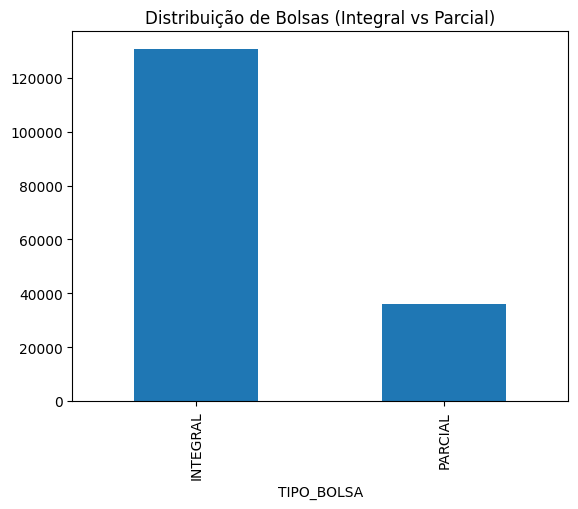

In [13]:
base['TIPO_BOLSA'].value_counts().plot(kind='bar')
plt.title('Distribuição de Bolsas (Integral vs Parcial)')
plt.show()

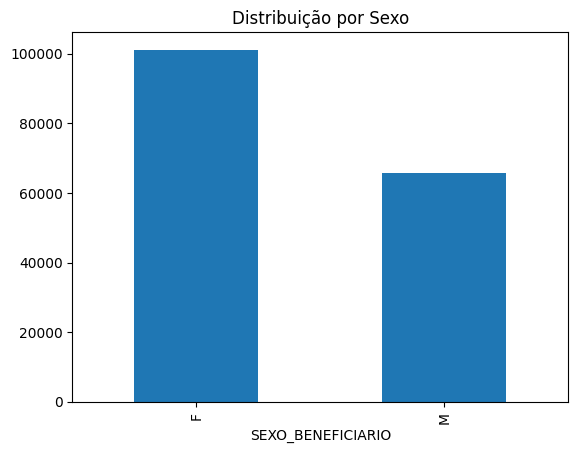

In [14]:
base['SEXO_BENEFICIARIO'].value_counts().plot(kind='bar')
plt.title('Distribuição por Sexo')
plt.show()

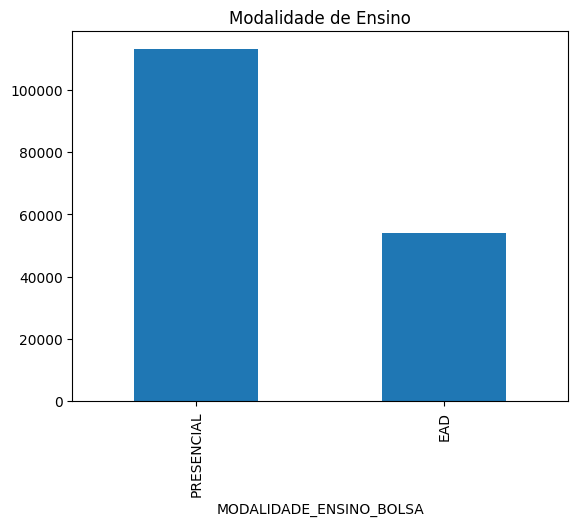

In [15]:
base['MODALIDADE_ENSINO_BOLSA'].value_counts().plot(kind='bar')
plt.title('Modalidade de Ensino')
plt.show()

# ETAPA 4 — SELEÇÃO DE VARIÁVEIS

In [16]:
base = base[['TIPO_BOLSA', 'SEXO_BENEFICIARIO', 'RACA_BENEFICIARIO',
             'MODALIDADE_ENSINO_BOLSA', 'NOME_TURNO_CURSO_BOLSA']]

In [17]:
base.head()

,TIPO_BOLSA,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,MODALIDADE_ENSINO_BOLSA,NOME_TURNO_CURSO_BOLSA
0,INTEGRAL,F,Parda,EAD,CURSO A DISTÂNCIA
1,INTEGRAL,M,Parda,EAD,CURSO A DISTÂNCIA
2,INTEGRAL,M,Parda,PRESENCIAL,NOTURNO
3,PARCIAL,F,Branca,PRESENCIAL,MATUTINO
4,INTEGRAL,F,Branca,PRESENCIAL,MATUTINO


# ETAPA 5 — LABORIZAÇÃO (CRIAÇÃO DO TARGET)

1 = Bolsa Integral | 0 = Bolsa Parcial

In [18]:
base['target'] = (base['TIPO_BOLSA'] == 'INTEGRAL').astype(int)

In [19]:
base.head()

,TIPO_BOLSA,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,MODALIDADE_ENSINO_BOLSA,NOME_TURNO_CURSO_BOLSA,target
0,INTEGRAL,F,Parda,EAD,CURSO A DISTÂNCIA,1
1,INTEGRAL,M,Parda,EAD,CURSO A DISTÂNCIA,1
2,INTEGRAL,M,Parda,PRESENCIAL,NOTURNO,1
3,PARCIAL,F,Branca,PRESENCIAL,MATUTINO,0
4,INTEGRAL,F,Branca,PRESENCIAL,MATUTINO,1


# ETAPA 6 — TRATAMENTO DE DADOS

In [20]:
base['SEXO_BENEFICIARIO'] = base['SEXO_BENEFICIARIO'].astype('category').cat.codes
base['RACA_BENEFICIARIO'] = base['RACA_BENEFICIARIO'].astype('category').cat.codes
base['MODALIDADE_ENSINO'] = base['MODALIDADE_ENSINO_BOLSA'].astype('category').cat.codes
base['NOME_TURNO_CURSO'] = base['NOME_TURNO_CURSO_BOLSA'].astype('category').cat.codes

In [21]:
base = base.drop('TIPO_BOLSA', axis=1)

In [22]:
base = base.dropna()

In [23]:
base.head()

,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,MODALIDADE_ENSINO_BOLSA,NOME_TURNO_CURSO_BOLSA,target,MODALIDADE_ENSINO,NOME_TURNO_CURSO
0,0,4,EAD,CURSO A DISTÂNCIA,1,0,0
1,1,4,EAD,CURSO A DISTÂNCIA,1,0,0
2,1,4,PRESENCIAL,NOTURNO,1,1,3
3,0,1,PRESENCIAL,MATUTINO,0,1,2
4,0,1,PRESENCIAL,MATUTINO,1,1,2


# ETAPA 7 — SEPARAÇÃO DE DADOS (X e Y)

In [24]:
X = base.drop(['target', 'MODALIDADE_ENSINO_BOLSA', 'NOME_TURNO_CURSO_BOLSA'], axis=1)
y = base['target']

X.head()

,SEXO_BENEFICIARIO,RACA_BENEFICIARIO,MODALIDADE_ENSINO,NOME_TURNO_CURSO
0,0,4,0,0
1,1,4,0,0
2,1,4,1,3
3,0,1,1,2
4,0,1,1,2


# ETAPA 8 — NORMALIZAÇÃO

In [25]:
from sklearn.preprocessing import StandardScaler


In [26]:
scaler = StandardScaler()

In [27]:
X = scaler.fit_transform(X)

# ETAPA 9 — TREINAMENTO DO MODELO

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [30]:
modelo = GaussianNB()

In [31]:
modelo.fit(X_train, y_train)

GaussianNB()

#ETAPA 10 — AVALIAÇÃO

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix

In [33]:
y_pred = modelo.predict(X_test)

In [34]:
acc = accuracy_score(y_test, y_pred)
print("Acurácia do modelo:", acc)

Acurácia do modelo: 0.6116805530580032


In [35]:
confusion_matrix(y_test, y_pred)

array([[ 6811,  4113],
       [15322, 23803]])

In [36]:
# Certifique-se de que o DataFrame 'base' esteja em seu estado processado conforme as etapas anteriores (ETAPA 6).
# Caso contrário, por favor, execute as células da 'ETAPA 1' até a 'ETAPA 6' primeiro.

# ETAPA 7 — SEPARAÇÃO DE DADOS (X e Y)
# Este código é geralmente definido na célula 'opS1zsdDTmzM'
X = base.drop(['target', 'MODALIDADE_ENSINO_BOLSA', 'NOME_TURNO_CURSO_BOLSA'], axis=1)
y = base['target']

# ETAPA 8 — NORMALIZAÇÃO
# Este código é geralmente definido nas células 'AUjirJmtTyQg', 'igtgeZx0T6j9', '7yhqmGsGT-rh'
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)

# ETAPA 9 — TREINAMENTO DO MODELO
# Este código é geralmente definido nas células 'DdAIJtTsUgMT', 'YlTgTZ6zUjPR', 'r1rrIXBtUmus', 'b1GDIeZZUpSL'
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

modelo = GaussianNB()
modelo.fit(X_train, y_train)

# ETAPA 10 — AVALIAÇÃO - PREDIÇÃO
# Este código é geralmente definido na célula 'EQRr4VVPU0bc'
y_pred = modelo.predict(X_test)

# ETAPA 10 — AVALIAÇÃO - CLASSIFICATION REPORT
# Conteúdo original da célula DcDoyNekSLk2, agora com as variáveis definidas
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.30      0.62      0.41     10867
           1       0.85      0.60      0.71     39182

    accuracy                           0.61     50049
   macro avg       0.58      0.61      0.56     50049
weighted avg       0.73      0.61      0.64     50049



In [37]:
precision = 0.30
recall = 0.62
f1_score = 2 * (precision * recall) / (precision + recall)
print(f"{f1_score=}")

f1_score=0.4043478260869566
